Imports

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

Data collection and Processing

In [19]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Train-Test Split

In [20]:
X = df.drop(columns='target', axis=1)
Y = df['target']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)

Feature Scaling

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Models

In [22]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train_scaled, Y_train)

# Random Forest with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5)
grid_search.fit(X_train, Y_train)
rf_model = grid_search.best_estimator_

# Save models
joblib.dump(lr_model, 'models/logistic_regression.pkl')
joblib.dump(rf_model, 'models/random_forest.pkl')


FileNotFoundError: [Errno 2] No such file or directory: 'models/logistic_regression.pkl'

Evaluate Models

In [23]:
def evaluate_model(model, X_train, X_test, Y_train, Y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc = accuracy_score(Y_train, train_pred)
    test_acc = accuracy_score(Y_test, test_pred)

    print(f"--- {name} ---")
    print("Training Accuracy:", round(train_acc * 100,2), "%")
    print("Test Accuracy:", round(test_acc * 100,2), "%")
    print("\nClassification Report:\n", classification_report(Y_test, test_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(Y_test, test_pred))
    print("\n")

evaluate_model(lr_model, X_train_scaled, X_test_scaled, Y_train, Y_test, "Logistic Regression")
evaluate_model(rf_model, X_train, X_test, Y_train, Y_test, "Random Forest")


--- Logistic Regression ---
Training Accuracy: 98.9 %
Test Accuracy: 98.25 %

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
 [[41  1]
 [ 1 71]]


--- Random Forest ---
Training Accuracy: 100.0 %
Test Accuracy: 95.61 %

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
 [[39  3]
 [ 2 70]]




ROC Curve

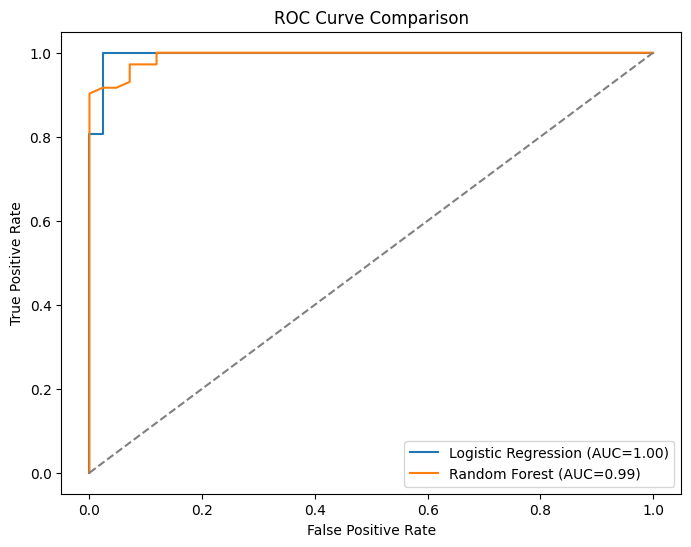

In [24]:
lr_probs = lr_model.predict_proba(X_test_scaled)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(Y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(Y_test, rf_probs)

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC={lr_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.2f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Feature Importance (Random Forest)

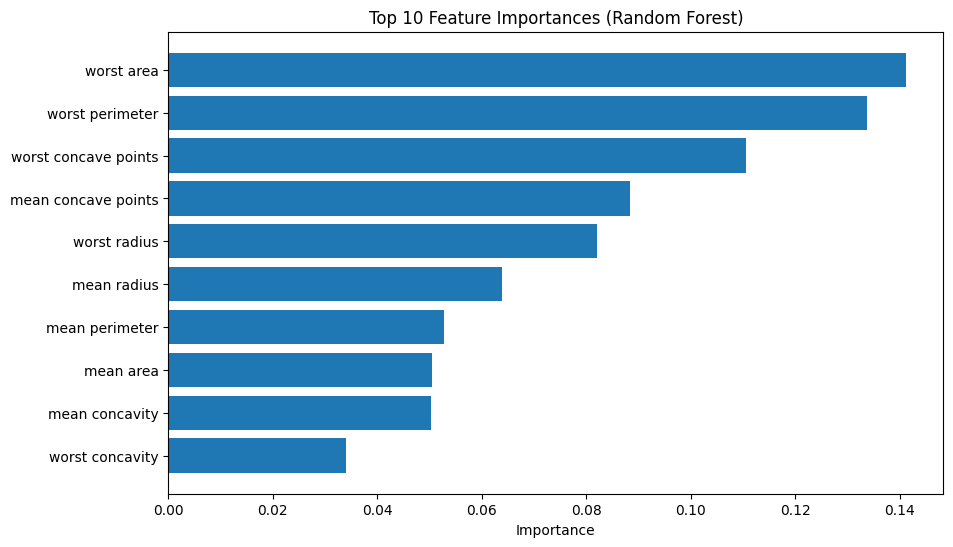

,Feature,Importance
23,worst area,0.141320
22,worst perimeter,0.133719
27,worst concave points,0.110514
7,mean concave points,0.088347
20,worst radius,0.082151
0,mean radius,0.063799
2,mean perimeter,0.052809
3,mean area,0.050409
6,mean concavity,0.050284
26,worst concavity,0.033928


In [25]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
plt.barh(feat_df['Feature'][:10][::-1], feat_df['Importance'][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()
feat_df.head(10)

Key Insights:
- Logistic Regression performs well due to scaled, linearly separable data.
- Random Forest slightly outperforms in capturing nonlinear patterns.
- ROC-AUC comparison demonstrates strong generalization for both models.
- Feature importance highlights the most predictive features influencing cancer classification.

Conclusion:

Both models achieve high accuracy. Random Forest provides interpretability via feature importance while Logistic Regression offers simplicity and efficiency.
